[[6.0882 4.8616 0.8014 0.5062]
 [4.8616 7.0408 0.5732 0.4556]
 [0.8014 0.5732 1.4778 0.2974]
 [0.5062 0.4556 0.2974 0.5442]]

[[-0.83733333]
 [ 0.37066667]
 [-2.296     ]
 [-0.95333333]]

[[19.1434  9.0356  9.7634  3.2394]
 [ 9.0356 11.8658  4.6232  2.4746]
 [ 9.7634  4.6232 12.2978  3.8794]
 [ 3.2394  2.4746  3.8794  2.4604]]

[[ 0.09266667]
 [-0.28733333]
 [ 0.502     ]
 [ 0.12666667]]

[[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]

[[ 0.74466667]
 [-0.08333333]
 [ 1.794     ]
 [ 0.82666667]]



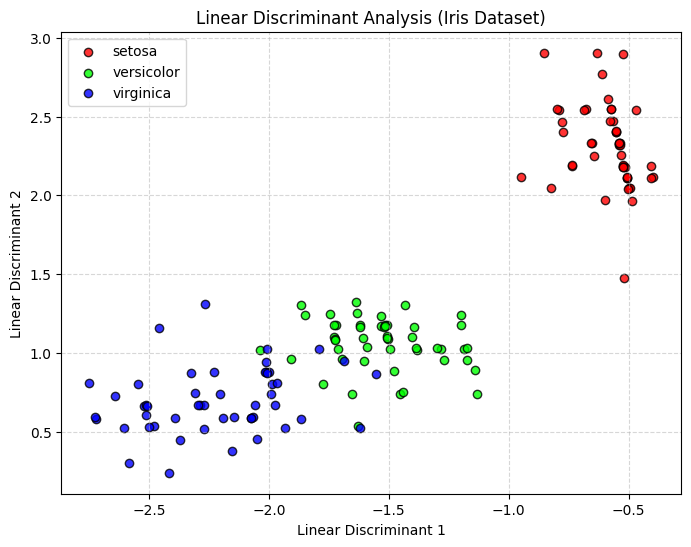

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

class LDADay07:
    def __init__(self, n_components):
        self.n_components = n_components
        self.linear_discriminants = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        class_labels = np.unique(y)

        # 1. Compute overall mean and class-wise means
        mean_overall = np.mean(X, axis=0)
        SW = np.zeros((n_features, n_features))
        SB = np.zeros((n_features, n_features))

        for c in class_labels:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)

             #1: Fully Vectorized SW Matrix ---
            X_centered = X_c - mean_c
            SW += X_centered.T @ X_centered
            print(SW)

            # 2: Clean Array Broadcasting for SB ---
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(-1, 1)
            print(f"\n{mean_diff}\n")
            SB += n_c * (mean_diff @ mean_diff.T)

        # 3. Solve the generalized eigenvalue problem
        # Adding a tiny regularization term to the diagonal avoids numerical instability
        SW += np.eye(n_features) * 1e-6
        A = np.linalg.inv(SW) @ SB
        
        eigenvalues, eigenvectors = np.linalg.eig(A)
        eigenvectors = eigenvectors.T
        
        # 4. Sort eigenvalues and eigenvectors in descending order
        sorted_indices = np.argsort(np.abs(eigenvalues))[::-1]
        
        # 5. Select the top k discriminant vectors
        self.linear_discriminants = eigenvectors[sorted_indices[:self.n_components]]

    def transform(self, X):
        # 6. Project the given dataset onto the new lower-dimensional subspace
        return np.real(X @ self.linear_discriminants.T)


# 7. Load Iris dataset and visualize the transformed data
if __name__ == "__main__":
    iris = load_iris()
    X = iris.data
    y = iris.target
    target_names = iris.target_names

    # Use the optimized class
    lda = LDADay07(n_components=2)
    lda.fit(X, y)
    X_projected = lda.transform(X)

    # Plotting code
    plt.figure(figsize=(8, 6))
    colors = ['#FF0000', '#00FF00', '#0000FF']
    
    for i, color, target_name in zip(range(3), colors, target_names):
        plt.scatter(
            X_projected[y == i, 0],
            X_projected[y == i, 1],
            color=color,
            alpha=0.8,
            edgecolors='k',
            label=target_name
        )
        
    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("Linear Discriminant Analysis (Iris Dataset)")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()